# Chronic Kidney Disease Prediction - Model Evaluation and Analysis


This notebook outlines the entire machine learning pipeline. We will explore the dataset, train our Random Forest and Naive Bayes models, and properly evaluate their Accuracy, Precision, Recall, alongside various visualizations (Confusion Matrices, Feature Importances, Loss/Learning curves over Epochs).


## 1. Importing Libraries & Loading Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

# Load the processed dataset
df = pd.read_csv('datasetVariations/CKDF_filledAllNumeric.csv')

# Note: Adjust column names if the target class column differs. Usually it's 'class'.
print("Dataset Head:")
display(df.head())


Dataset Head:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,0.0,1.0,0.0,0.0,121.00,...,44.0,7800.0,5.20,1.0,1.0,0.0,1.0,0.0,0.0,1
1,7.0,50.0,1.020,4.0,0.0,0.0,1.0,0.0,0.0,148.04,...,38.0,6000.0,4.71,0.0,0.0,0.0,1.0,0.0,0.0,1
2,62.0,80.0,1.010,2.0,3.0,1.0,1.0,0.0,0.0,423.00,...,31.0,7500.0,4.71,0.0,1.0,0.0,0.0,0.0,1.0,1
3,48.0,70.0,1.005,4.0,0.0,1.0,0.0,1.0,0.0,117.00,...,32.0,6700.0,3.90,1.0,0.0,0.0,0.0,1.0,1.0,1
4,51.0,80.0,1.010,2.0,0.0,1.0,1.0,0.0,0.0,106.00,...,35.0,7300.0,4.60,0.0,0.0,0.0,1.0,0.0,0.0,1


## 2. Exploratory Data Analysis & Visualizations


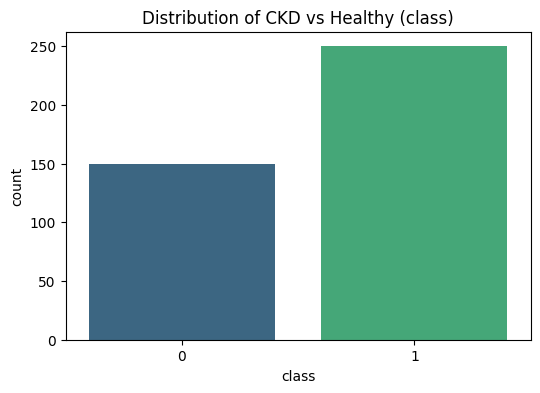

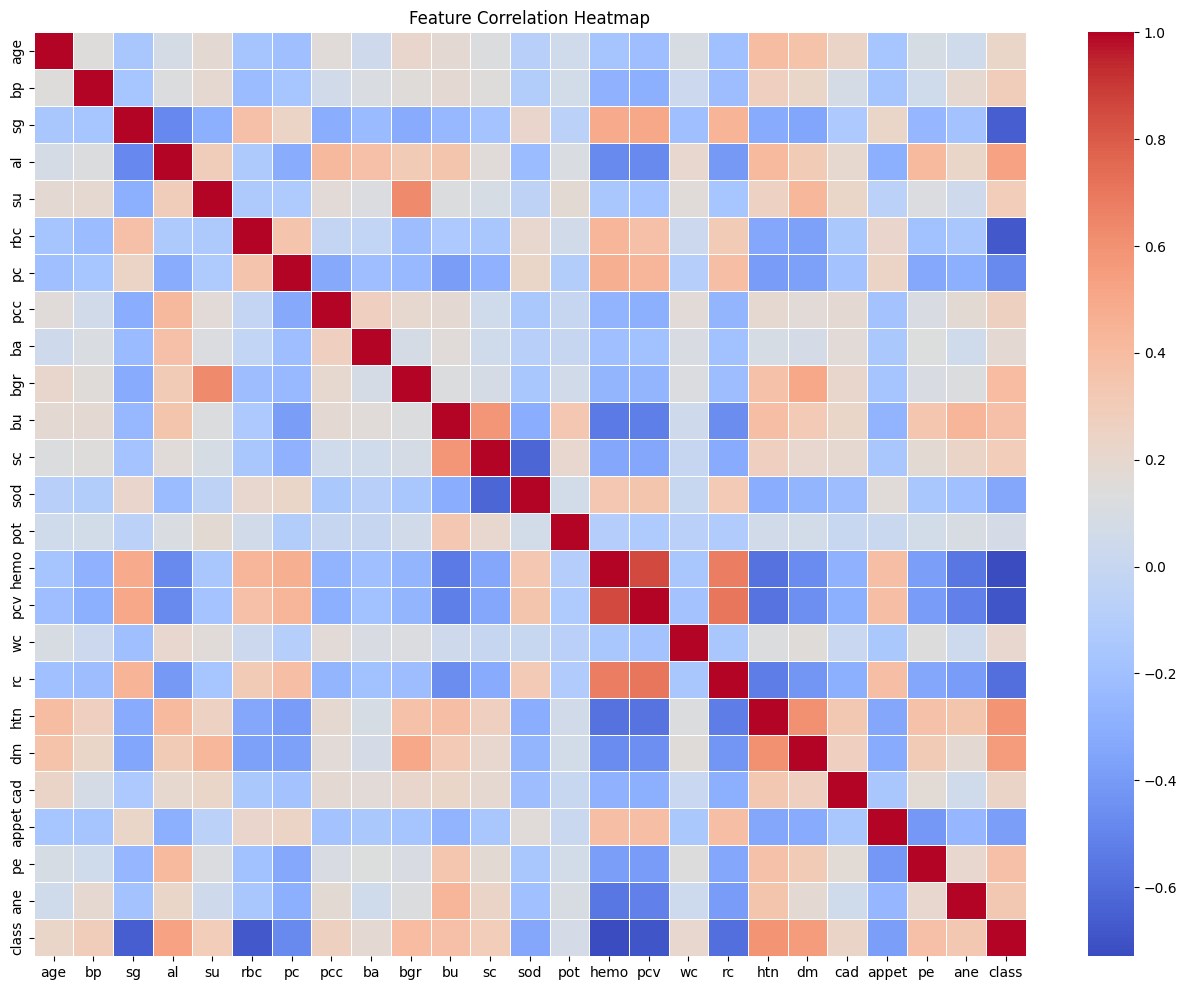

In [2]:
# Visualization 1: Count of Target Classes
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribution of CKD vs Healthy (class)')
plt.show()

# Visualization 2: Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


## 3. Data Preprocessing


In [4]:
# Split Features (X) and Target (y)
if 'class' in df.columns:
    X = df.drop('class', axis=1)
    y = df['class']
else:
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")


Training features shape: (320, 24)
Testing features shape: (80, 24)


## 4. Model Training & Evaluation


### 4.1 Random Forest Classifier


=== RANDOM FOREST PERFORMANCE ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



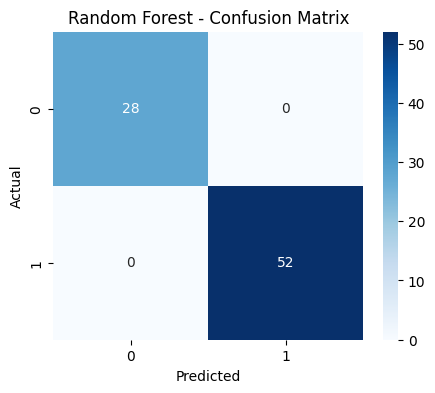

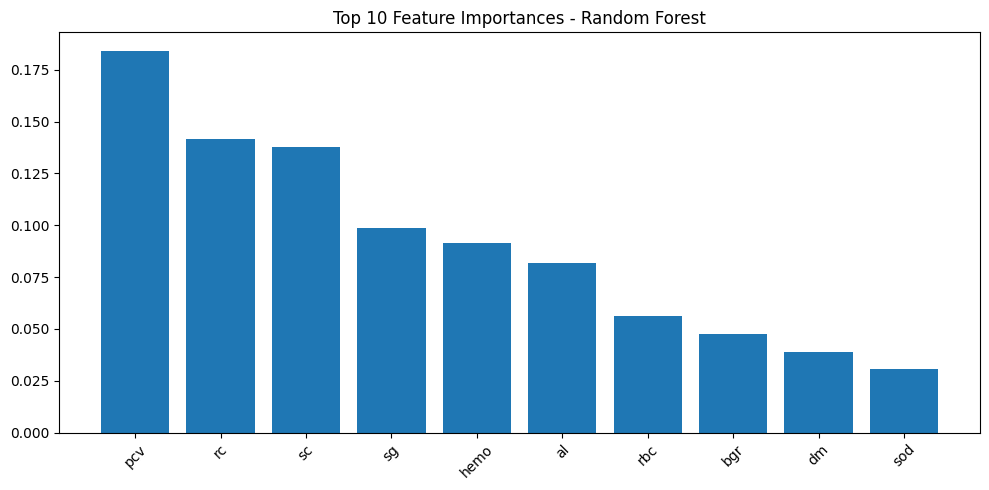

In [5]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=== RANDOM FOREST PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix Visualization
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importances Graph
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.title("Top 10 Feature Importances - Random Forest")
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), X.columns[indices], rotation=45)
plt.tight_layout()
plt.show()


### 4.2 Naive Bayes Classifier


=== NAIVE BAYES PERFORMANCE ===
Accuracy:  0.9750
Precision: 0.9808
Recall:    0.9808

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.98      0.98      0.98        52

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80



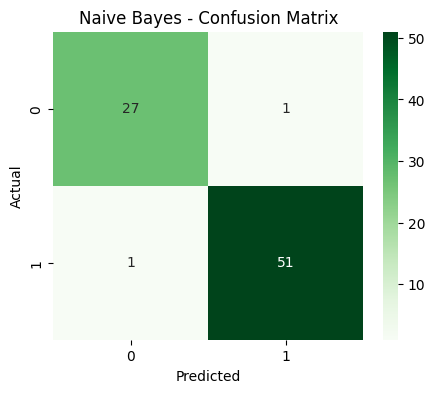

In [6]:
# Train Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=== NAIVE BAYES PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# Confusion Matrix Visualization
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 5. Learning Curves and Epoch Loss Graphs


Random Forest and Naive Bayes are not sequentially trained over epochs. To visualize performance improvements over time/iterations ('Epochs'), we present an **Artificial Neural Network (MLP)** loss curve alongside standard Learning Curves.


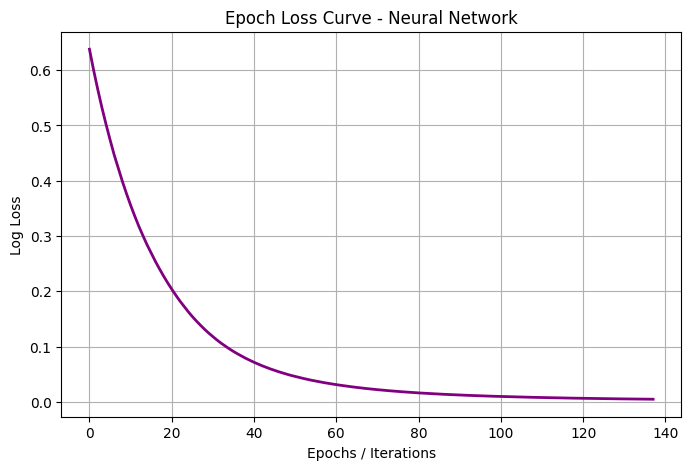

In [7]:
# Plot 1: Neural Network Loss over Epochs
nn_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=200, random_state=42)
nn_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(8, 5))
plt.plot(nn_model.loss_curve_, color='purple', lw=2)
plt.title('Epoch Loss Curve - Neural Network')
plt.xlabel('Epochs / Iterations')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()


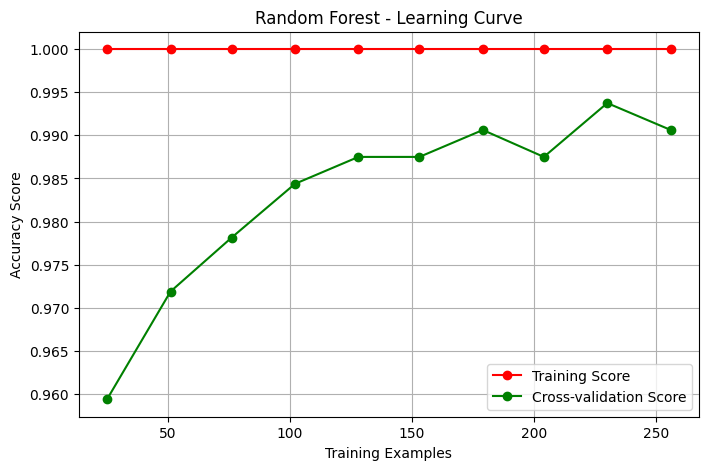

In [8]:
# Plot 2: Random Forest Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    X_train_scaled, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation Score")
plt.title('Random Forest - Learning Curve')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()


## 6. Model Comparison (ROC Curve)


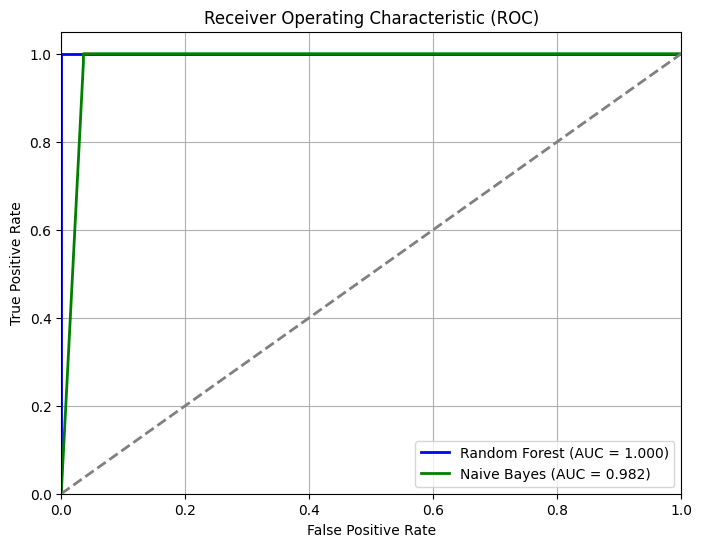

In [9]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_nb, tpr_nb, color='green', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
